In [7]:
import json

import colorcet
import h5py
import matplotlib.pyplot as plt
import numpy as np

from lib.plots import set_axis
from lib.stats import fit_power_law

In [32]:
config_id = 3
filename = f"_outputs/output-{config_id}.h5"

with h5py.File(filename, "r") as store:
    phase_store = store["production"]
    config = json.loads(phase_store["metadata/config_source"][()])
    config_used = json.loads(phase_store["metadata/config"][()])

    positions_history = []
    for step_key in phase_store[".steps"]:
        positions = phase_store[step_key]["positions"][:]
        positions_history.append(positions)
    positions_history = np.array(positions_history)

In [33]:
sampling_config = config["sampling"]
frame_interval = sampling_config["timestep"] * sampling_config["sampling_interval"]
diffusion_timescale = 1 / config["chain"]["monomer_mobility"]

In [34]:
def collect_msds(
    paths: np.ndarray,  # (time, particle, dim)
    lag: int,
) -> np.ndarray:
    squared_dists = np.zeros((lag, paths.shape[1]))
    for t in range(0, paths.shape[0] - lag):
        delta = paths[t:t + lag] - paths[t]
        squared_dists += (delta ** 2).sum(-1)
    return squared_dists / (paths.shape[0] - lag)


def subtract_centroid(paths: np.ndarray) -> np.ndarray:
    return paths - paths.mean(axis=1, keepdims=True)

In [35]:
with_decentroid = True

lag_frames = 10
lag_time = lag_frames * frame_interval

paths = positions_history
if with_decentroid:
    paths = subtract_centroid(paths)

msd = collect_msds(paths, lag=lag_frames).mean(1)

x = frame_interval * np.arange(len(msd))
y = msd
alpha, beta = fit_power_law(x, y)

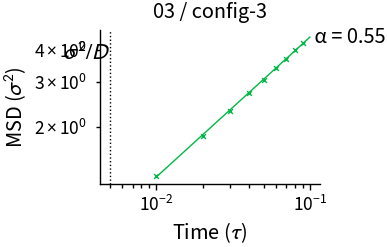

In [36]:
color = "C:g"

fig, ax = plt.subplots(figsize=(2.0, 1.3))

x = np.arange(len(msd)) * frame_interval
y = msd
ax.scatter(x, y, s=3, marker="x", color=color)

x = np.logspace(np.log10(frame_interval), np.log10(lag_time), num=100)
y = x**alpha * beta
ax.plot(x, y, color=color)

x = lag_time
y = lag_time**alpha * beta
s = " α = %.2f" % alpha
ax.text(x, y, s, ha="left", va="center")

x = diffusion_timescale
y = msd.max()
s = r" $ \sigma^2 / D $"
ax.text(x, y, s, ha="right", va="top")
ax.axvline(x, ls=":", zorder=1)

ax.set_xlabel(r"Time ($ \tau $)")
ax.set_ylabel(r"MSD ($ \sigma^2 $)")
ax.set_title(f"03 / config-{config_id}")

ax.set_xscale("log")
ax.set_yscale("log")

set_axis(ax, "left bottom")

pass